In [1]:
#Load a sample loan dataset

#Clean / preprocess

#Train a Decision Tree

#Evaluate performance (accuracy, confusion matrix)

#Visualize tree

#Show feature importance

In [3]:
import pandas as pd

# Example: load a CSV file (replace path with your file)
#download loan.csv from kaggle 
df = pd.read_csv("D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\adv ml-Tree Models-12\\loan.csv")

# Let’s inspect
print(df.head())
print(df.info())
print(df.isnull().sum())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [4]:
# Drop Loan_ID (not useful)
df = df.drop(columns=['Loan_ID'])

# Handle missing values — simple methods
# For simplicity: fill numeric columns with median, categorical with mode
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Convert target to 0 / 1
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})

# Convert categorical variables to numeric via one-hot or label encoding
df = pd.get_dummies(df, drop_first=True)

print(df.head())


   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Loan_Status  Gender_Male  Married_Yes  Dependents_1  \
0             1.0            1         True        False         False   
1             1.0            0         True         True          True   
2             1.0            1         True         True         False   
3             1.0            1         True         True         False   
4             1.0            1         True        False         False   

   Dependents_2  Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0         False          False                   Fa

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7668\1354544891.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7668\1354544891.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Features and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [6]:
#evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8108108108108109
Classification Report:
              precision    recall  f1-score   support

    Rejected       0.77      0.57      0.65        58
    Approved       0.82      0.92      0.87       127

    accuracy                           0.81       185
   macro avg       0.80      0.75      0.76       185
weighted avg       0.81      0.81      0.80       185

Confusion Matrix:
[[ 33  25]
 [ 10 117]]


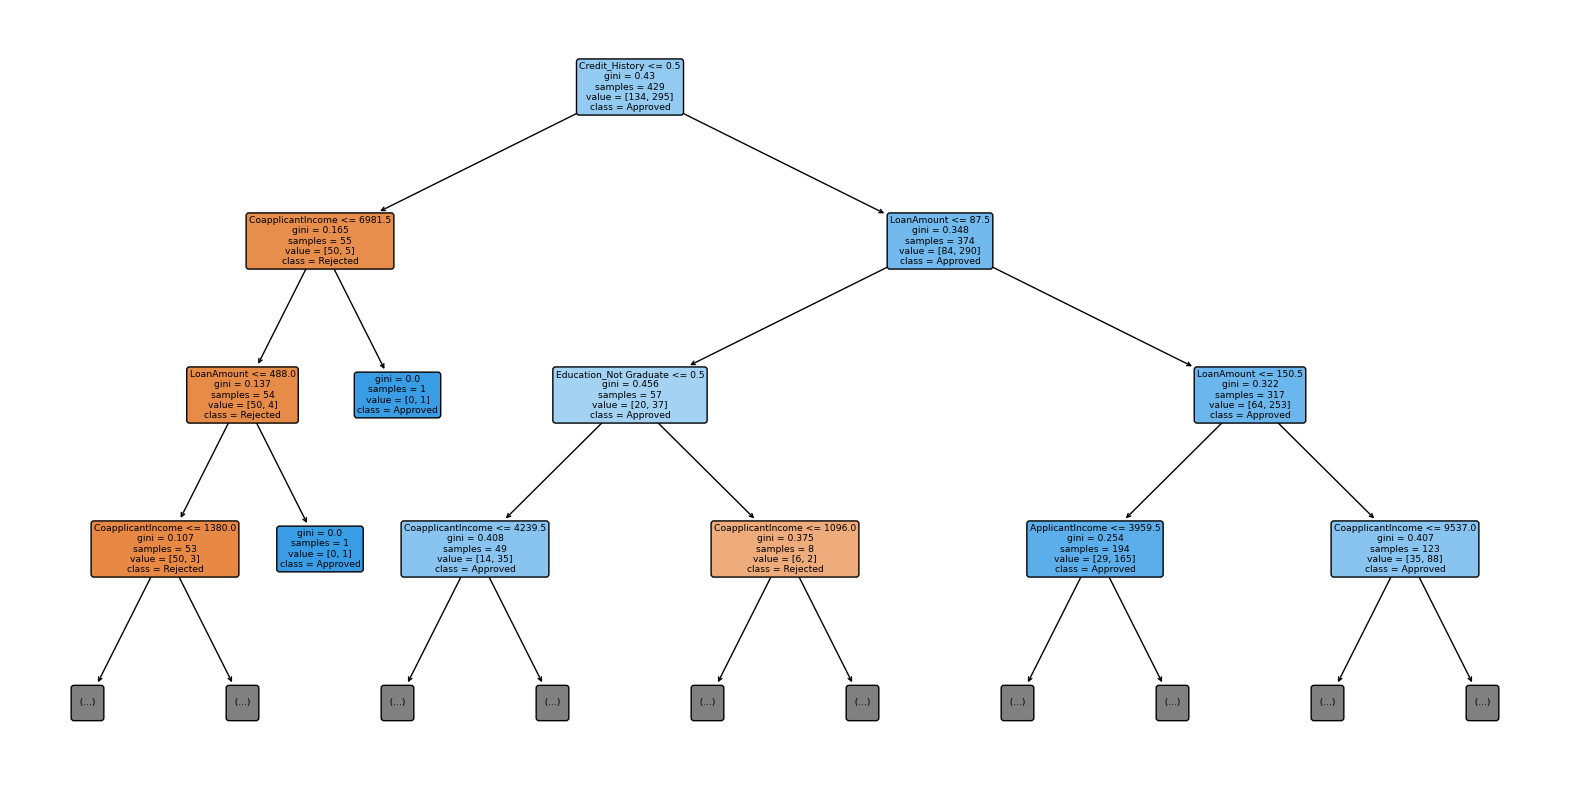

In [8]:
#visualize
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    max_depth=3  # You can limit depth for clarity
)
plt.show()


In [ ]:
#assignment - change max-depth and observe the decision tree

Feature importances:
Credit_History : 0.6887
CoapplicantIncome : 0.1417
LoanAmount : 0.1018
Education_Not Graduate : 0.0454
ApplicantIncome : 0.0223
Property_Area_Urban : 0.0000
Property_Area_Semiurban : 0.0000
Self_Employed_Yes : 0.0000
Dependents_3+ : 0.0000
Dependents_2 : 0.0000
Dependents_1 : 0.0000
Married_Yes : 0.0000
Gender_Male : 0.0000
Loan_Amount_Term : 0.0000


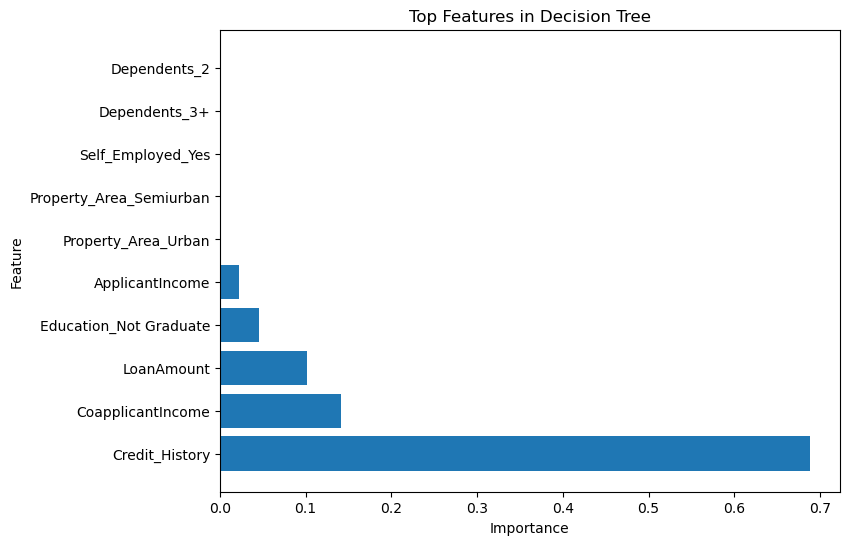

In [9]:
#feature importance
import numpy as np

importances = dt.feature_importances_
features = X.columns
idx = np.argsort(importances)[::-1]

print("Feature importances:")
for i in idx:
    print(f"{features[i]} : {importances[i]:.4f}")

# (Optional) bar plot
plt.figure(figsize=(8,6))
plt.barh(features[idx][:10], importances[idx][:10])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features in Decision Tree")
plt.show()
